# FC 온라인 인벤 크롤링

## 데이터 수집 환경 조성

### 필요 라이브러리 호출

In [1]:
import numpy as np
import pandas as pd
import requests
from bs4 import BeautifulSoup
from openpyxl import Workbook
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver.common.action_chains import ActionChains

from konlpy.tag import Kkma, Komoran, Okt, Hannanum # 토큰화
from konlpy.tag import Mecab # 토큰화
from collections import Counter
from wordcloud import WordCloud
import nltk
import re

import json
from time import sleep
import matplotlib.pyplot as plt
from matplotlib import font_manager, rc
plt.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] =False

# Warnings 제거
import warnings
warnings.filterwarnings('ignore')

---

## 데이터 크롤링

### 1) 분석 실시할 선수 카드 입력

In [2]:
# 선수 이름, 시즌 카드 받아오기
player_search = input("선수 이름을 입력해주세요.")
season_icon = input("시즌 아이콘을 선택해주세요.")

In [3]:
# 선수 이름, 시즌 카드 확인
print(player_search)
print(season_icon)

손흥민
22 UEFA Champions League


### 2) 데이터 스크래핑 진행(Selenium)

In [3]:
# 드라이버 생성
driver = webdriver.Chrome()
wait= WebDriverWait(driver,3)

# 사이트 접속하기
driver.get('https://fifaonline4.inven.co.kr/dataninfo/player/')
sleep(3)


################### 선수 페이지로 이동하기 ###################
# 시즌 아이콘 선택
season_icon = wait.until(EC.element_to_be_clickable((By.CSS_SELECTOR, '.fifa4.value.season.clearfix > label.checkbox > div[title="22 UEFA Champions League"]')))
season_icon.click()

# 선수 이름 검색창 클릭
search_box = wait.until(EC.element_to_be_clickable((By.CSS_SELECTOR, '.fifa4.value.name_search.clearfix > .input')))
search_box.click()

# 선수 이름 입력
name_input = wait.until(EC.visibility_of_element_located((By.CSS_SELECTOR,'.fifa4.value.name_search.clearfix > .input')))
name_input.send_keys(player_search)

# 검색 버튼 클릭
search_btn = wait.until(EC.element_to_be_clickable((By.CSS_SELECTOR,'.fifa4.btn_area.clearfix > .btn.search')))
search_btn.click()

# 웹페이지 끝까지 스크롤
# 맨 위로 스크롤링
driver.execute_script('window.scrollTo(0,0)')

# 처음 웹페이지가 로딩 되었을 때, (불러와진) 높이를 가져오기
last_height = driver.execute_script('return document.body.scrollHeight')

# 반복 및 끝까지 스크롤링
while True:
    # 첫 스크롤링 진행
    driver.execute_script('window.scrollTo(0, document.body.scrollHeight)')
    
    # 새로운 페이지가 보일 때까지 대기
    sleep(1)

    # 현재 높이
    new_height = driver.execute_script('return document.body.scrollHeight')

    if new_height == last_height:
        break
        
    last_height = new_height

# 선수 카드 클릭
player_card = wait.until(EC.presence_of_element_located((By.CSS_SELECTOR,'.fifa4.player_info.clearfix > a.fifa4.text_area > span.fifa4.name')))
player_card.click()



################### 모든 카드 리뷰 받아오기 ###################
# 리뷰 리스트 생성
comment_list = []

# 웹페이지 끝까지 스크롤
# 맨 위로 스크롤링
driver.execute_script('window.scrollTo(0,0)')

# 처음 웹페이지가 로딩 되었을 때, (불러와진) 높이를 가져오기
last_height = driver.execute_script('return document.body.scrollHeight')

# 반복 및 끝까지 스크롤링
while True:
    # 첫 스크롤링 진행
    driver.execute_script('window.scrollTo(0, document.body.scrollHeight)')
    
    # 새로운 페이지가 보일 때까지 대기
    sleep(1)

    # 현재 높이
    new_height = driver.execute_script('return document.body.scrollHeight')

    if new_height == last_height:
        break
        
    last_height = new_height

# 첫페이지 리뷰 리스트에 추가
comments = driver.find_elements('css selector', 'span.comment')
for comment in comments:
    comment_list.append(comment.text.replace('\n',' '))

# 다음페이지 클릭
next_text = wait.until(EC.element_to_be_clickable((By.CSS_SELECTOR, 'span.nexttext')))
next_text.click()

sleep(5)

# 광고 숨기기
driver.execute_script("document.querySelector('div.InstreamDom_player_1y46y').style.display = 'none';")

# 10페이지까지 반복(10페이지 초과하는 리뷰는 집계X)
for i in range(11):
    comments = driver.find_elements('css selector', 'span.comment')
    for comment in comments:
        comment_list.append(comment.text.replace('\n',' '))
    
    sleep(3)
    # 웹페이지 끝까지 스크롤
    # 맨 위로 스크롤링
    driver.execute_script('window.scrollTo(0,0)')

    # 처음 웹페이지가 로딩 되었을 때, (불러와진) 높이를 가져오기
    last_height = driver.execute_script('return document.body.scrollHeight')

    # 반복 및 끝까지 스크롤링
    while True:
        # 첫 스크롤링 진행
        driver.execute_script('window.scrollTo(0, document.body.scrollHeight)')
        
        # 새로운 페이지가 보일 때까지 대기
        sleep(1)

        # 현재 높이
        new_height = driver.execute_script('return document.body.scrollHeight')

        if new_height == last_height:
            break
            
        last_height = new_height

    # 다음 페이지 버튼 클릭
    next_text = wait.until(EC.element_to_be_clickable((By.CSS_SELECTOR, 'span.nexttext')))
    next_text.click()
    sleep(5)

    i+=1


################### 선수 정보 스크래핑(BeautifulSoup) ###################

# 선수 정보 페이지(현재페이지) 받아오기
res = requests.get(driver.current_url)

# 드라이버 종료
sleep(5)
driver.quit()

# 선수 정보 받아오기
soup = BeautifulSoup(res.text, 'html.parser')

player_stat = soup.select('ul.fifa4.tooltip_position.clearfix span.score')[0].get_text() # 스탯
player_age = soup.select('ul.fifa4.state.clearfix')[0].get_text().strip().split('\n')[0] # 나이
player_pay = soup.select('ul.fifa4.state.clearfix')[0].get_text().strip().split('\n')[1].split(' ')[1].strip('[').strip(']') # 급여
player_bodyform = soup.select('ul.fifa4.state.clearfix')[0].get_text().strip().split('\n')[2] # 체형
player_backnum = soup.select('ul.fifa4.state.clearfix')[0].get_text().strip().split('\n')[3].split(' ')[2] # 등번호
player_country = soup.select('ul.fifa4.state.clearfix')[0].get_text().strip().split('\n')[7].strip() # 국적
player_class = soup.select('ul.fifa4.state.clearfix')[0].get_text().strip().split('\n')[8] # 클래스

player_info = {
    '능력치' : int(player_stat),
    '나이' : player_age,
    '급여' : int(player_pay),
    '체형' : player_bodyform,
    '등번호' : player_backnum,
    '국적' : player_country,
    '클래스' : player_class
}

# 선수 정보 확인
print(player_info)


{'능력치': 105, '나이': '1992.07.08[32세]', '급여': 24, '체형': '183cm / 78kg / 보통(고유)', '등번호': '7번', '국적': '대한민국', '클래스': '월드클래스'}


- 선택한 카드 리뷰 리스트 확인

In [4]:
comment_list[0:3]

['금카 아직 현역이다 7조대 가성비 금흥민 감차 치달 퍼터 중거리 미쳤음 체감까지 괜찮고 금카케미까지 받을 수 있어서 메리트 있음 진짜 솔직히 24토티은카 8조짜리랑 차이가 없음 걍 진짜 좋음..',
 '금카 사용중 CAP보다는 확실히 우위의 22시즌 나머지 120오버롤 대비해서 다 거기서 거기이고 이게 제일 가겨대비 성능도 좋음 딱 윙어에 10조 이상 금카 흥민이 쓰는건 조금 낭비임 이걸로 솔직히 흥민이는 FC온라인 종결임',
 ' 24토티+5 쓰다가 급여 때문에 이거 금카로 넘어왔는데 솔직히 블라인드 테스트하면 못 맞출 것 같음 비슷비슷한 듯']

In [5]:
comment_list

['금카 아직 현역이다 7조대 가성비 금흥민 감차 치달 퍼터 중거리 미쳤음 체감까지 괜찮고 금카케미까지 받을 수 있어서 메리트 있음 진짜 솔직히 24토티은카 8조짜리랑 차이가 없음 걍 진짜 좋음..',
 '금카 사용중 CAP보다는 확실히 우위의 22시즌 나머지 120오버롤 대비해서 다 거기서 거기이고 이게 제일 가겨대비 성능도 좋음 딱 윙어에 10조 이상 금카 흥민이 쓰는건 조금 낭비임 이걸로 솔직히 흥민이는 FC온라인 종결임',
 ' 24토티+5 쓰다가 급여 때문에 이거 금카로 넘어왔는데 솔직히 블라인드 테스트하면 못 맞출 것 같음 비슷비슷한 듯',
 '3년째 챔스거주중 키보드유저 캡금이랑 다를거없고 몸싸움이랑 드리블은 여전히 너무 안좋다 바로 이적시장침투',
 '금카 한번 써보고 싶습니다 부탁드립니다 형님들!',
 '다른시즌에 비해서는 모르겠는데 22챔 금카 공미로두고 중거리 개맛있게먹는중 궤적이 진짜다름 금카 개좋음진짜 윗시즌금카부터는 14조라서 이게 가성비 국밥임',
 '금카 하한 전재산 제발팔아주세요ㅕ',
 '금카 상한 알박 3일째 제발 팔아주세요,.,,',
 '이거 금카 캐미받고 톱 어떤가요',
 '** 삭제된 글입니다 **',
 '현역케미가 없는데유',
 '요 며칠간 24토티 손흥민 은카 사용해보니까 23토티, 22챔스 8카보다 위치선정, 침투가 좋았음  참여도 3/3이 아니라 3/2인 느낌임  인벤 데이터 베이스를 어떻게 분석하는 지는 모르겠지만 본가 손흥민은 참여도 3/2임   22 챔스 금카 손흥민 , 24토티 손흥민 둘다 사용해본 결과 24토티 손흥민 5카로 정착함  이유는 24토티가 확실히 똑똑했고 골 포인트가 더 높았고 1대1 상황에서 24토티가 더 안정적임  어시스트 횟수도 24토티 손흥민 5카가 확실히 많았음  24토티는 st , cf , lw , rw로 사용했을때 패마로 특성단 22챔 금카보다 연계가 좋아서 포메를 다양하게 사용하기 좋았음   기존 손흥민 카드들이랑 비교했을 때 기존 성능 업그레이드는 당연하고 몸싸움이 진짜 많이 좋

---

## 텍스트 사전 준비작업

### 1) 텍스트 전처리

#### 형태소 토큰화

In [70]:
# # Mecab활용 형태소 토큰화
# mecab = Mecab()
# tokens = [mecab.morphs(word) for word in comment_list]

# # 사전과 단어를 매칭 시키기 위해서 2차원 리스트를 1차원으로 변환
# tokens = list(map(lambda x : " ".join(x), tokens))

# # 확인
# tokens[:11]

In [6]:
# 한국어 형태소 분석기 호출
okt = Okt()
kkma = Kkma()
komoran = Komoran()
hannanum = Hannanum()

#### 클렌징(특수문자 삭제, 대소문자 변경)

In [7]:
result_list = []
for sentence in comment_list:
    okt_token = okt.pos(sentence)
    
    # 한국어, 숫자, 영어만 남기기
    result = []
    for token, pos in okt_token:  
        if re.match('^[a-zA-Z가-힣]+', token): 
            result.append((token,pos))

        # 결과 리스트에 저장
        result_list.append(result)

# 1차원 리스트로 변환(flatten)
tokens_list = [item for sublist in result_list for item in sublist] 
tokens_list

[('금카', 'Noun'),
 ('아직', 'Adverb'),
 ('현역', 'Noun'),
 ('이다', 'Josa'),
 ('대', 'Foreign'),
 ('가성', 'Noun'),
 ('비', 'Noun'),
 ('금흥민', 'Noun'),
 ('감차', 'Noun'),
 ('치달', 'Noun'),
 ('퍼터', 'Noun'),
 ('중거리', 'Noun'),
 ('미쳤음', 'Adjective'),
 ('체감', 'Noun'),
 ('까지', 'Josa'),
 ('괜찮고', 'Adjective'),
 ('금카', 'Noun'),
 ('케미', 'Noun'),
 ('까지', 'Josa'),
 ('받을', 'Verb'),
 ('수', 'Noun'),
 ('있어서', 'Adjective'),
 ('메리트', 'Noun'),
 ('있음', 'Adjective'),
 ('진짜', 'Noun'),
 ('솔직히', 'Adjective'),
 ('토티', 'Noun'),
 ('은카', 'Noun'),
 ('짜리랑', 'Foreign'),
 ('차이', 'Noun'),
 ('가', 'Josa'),
 ('없음', 'Adjective'),
 ('걍', 'Adverb'),
 ('진짜', 'Noun'),
 ('좋음', 'Adjective'),
 ('금카', 'Noun'),
 ('아직', 'Adverb'),
 ('현역', 'Noun'),
 ('이다', 'Josa'),
 ('대', 'Foreign'),
 ('가성', 'Noun'),
 ('비', 'Noun'),
 ('금흥민', 'Noun'),
 ('감차', 'Noun'),
 ('치달', 'Noun'),
 ('퍼터', 'Noun'),
 ('중거리', 'Noun'),
 ('미쳤음', 'Adjective'),
 ('체감', 'Noun'),
 ('까지', 'Josa'),
 ('괜찮고', 'Adjective'),
 ('금카', 'Noun'),
 ('케미', 'Noun'),
 ('까지', 'Josa'),
 ('받을', 'Verb'),


#### 필터링 / 스톱워드(의미없는 단어) 제거

In [8]:
# 불용어 제외하기
stopwords = []  # 불필요한 단어 리스트 stopwords 생성
# 일차 클렌징된 결과를 보고 제거하고 싶은 문자 불용어 사전에 추가
stopwords.append('수')
stopwords.append('ㅋ')
stopwords.append('ㅋㅋ')
stopwords.append('ㅋㅋㅋ')
stopwords.append('있음')
stopwords.append('선수')
stopwords.append('있어서')
stopwords.append('한국')
stopwords.append('진짜')
stopwords.append('8조')
stopwords.append('짜리랑')
stopwords.append(player_search)

cleaned_token1 = [] 
for word in tokens_list: 
    if (len(word[0]) != 1) and (word[0] not in stopwords) and word[1] not in ["Josa", "Eomi", "Punctuation"]:  
        cleaned_token1.append(word[0])  # token을 리스트에 더해준다

cleaned_token1

['금카',
 '아직',
 '현역',
 '가성',
 '금흥민',
 '감차',
 '치달',
 '퍼터',
 '중거리',
 '미쳤음',
 '체감',
 '괜찮고',
 '금카',
 '케미',
 '받을',
 '메리트',
 '솔직히',
 '토티',
 '은카',
 '차이',
 '없음',
 '좋음',
 '금카',
 '아직',
 '현역',
 '가성',
 '금흥민',
 '감차',
 '치달',
 '퍼터',
 '중거리',
 '미쳤음',
 '체감',
 '괜찮고',
 '금카',
 '케미',
 '받을',
 '메리트',
 '솔직히',
 '토티',
 '은카',
 '차이',
 '없음',
 '좋음',
 '금카',
 '아직',
 '현역',
 '가성',
 '금흥민',
 '감차',
 '치달',
 '퍼터',
 '중거리',
 '미쳤음',
 '체감',
 '괜찮고',
 '금카',
 '케미',
 '받을',
 '메리트',
 '솔직히',
 '토티',
 '은카',
 '차이',
 '없음',
 '좋음',
 '금카',
 '아직',
 '현역',
 '가성',
 '금흥민',
 '감차',
 '치달',
 '퍼터',
 '중거리',
 '미쳤음',
 '체감',
 '괜찮고',
 '금카',
 '케미',
 '받을',
 '메리트',
 '솔직히',
 '토티',
 '은카',
 '차이',
 '없음',
 '좋음',
 '금카',
 '아직',
 '현역',
 '가성',
 '금흥민',
 '감차',
 '치달',
 '퍼터',
 '중거리',
 '미쳤음',
 '체감',
 '괜찮고',
 '금카',
 '케미',
 '받을',
 '메리트',
 '솔직히',
 '토티',
 '은카',
 '차이',
 '없음',
 '좋음',
 '금카',
 '아직',
 '현역',
 '가성',
 '금흥민',
 '감차',
 '치달',
 '퍼터',
 '중거리',
 '미쳤음',
 '체감',
 '괜찮고',
 '금카',
 '케미',
 '받을',
 '메리트',
 '솔직히',
 '토티',
 '은카',
 '차이',
 '없음',
 '좋음',
 '금카',
 '아직',
 '현역',
 '가성',
 '금흥민',
 '감차

In [9]:
# 클렌징된 단어들 빈도수 카운팅
counts = Counter(cleaned_token1)
counts

Counter({'토티': 26400,
         '체감': 20005,
         '그냥': 11902,
         '사용': 11376,
         '침투': 10452,
         '시즌': 10067,
         '움직임': 9642,
         '느낌': 9586,
         '무난': 9416,
         '은카': 9024,
         '기준': 8988,
         '수비': 8919,
         '쓰고': 8257,
         '몸싸움': 8232,
         '스텟': 7865,
         '박스': 7855,
         '아니라': 7529,
         '하면': 7424,
         '추천': 7278,
         '호날두': 7238,
         '아니지만': 7238,
         '비슷함': 7238,
         '근데': 5870,
         '좋은': 5833,
         '챔스': 5769,
         '급여': 5506,
         '주고': 5380,
         '정도': 5271,
         '슈팅': 5239,
         '비교': 5086,
         '개인': 5049,
         '좋게': 5003,
         '유저': 4830,
         '속도': 4783,
         '제외': 4444,
         '귀속': 4416,
         '왔다': 4307,
         '갔다': 4307,
         '뚫고': 4246,
         '않음': 4191,
         '떨어지면': 4092,
         '않고': 4081,
         '하는': 4076,
         '봐서': 3938,
         '이제': 3933,
         '보지': 3872,
         '중거리': 383

In [10]:
# 전체 token 개수
print(len(cleaned_token1))  

# unique token 개수
print(len(set(cleaned_token1)))  

1018001
1167


---

## 감정 분석

### 1) Lexicon 기반 감정 분석
- 감정 사전을 활용해 각 단어에 긍정 또는 부정 점수를 부여.

- 감정 점수 = 긍정 단어의 합 - 부정 단어의 합으로 문장의 감정 점수를 계산.

- 간단하지만 도메인 특화 감정을 제대로 반영하기 어렵다는 한계를 가지고 있음
    - 해당 한계 극복을 위해

#### 사전 불러오기
- KNU 감성어 사전

- 감성어 사전 출처 : https://github.com/park1200656/KnuSentiLex/tree/master/KnuSentiLex/data

In [12]:
# 사전 불러오기
with open('SentiWord_info.json', encoding='utf-8-sig', mode='r') as f: 
  word_info = json.load(f)

word_df = pd.DataFrame(word_info)
word_df

,word,word_root,polarity
0,(-;,(,1
1,(;_;),(;_;),-1
2,(^^),(^^),1
3,(^-^),(^-^),1
4,(^^*,(,1
...,...,...,...
14842,알쏭달쏭하다,알쏭달쏭,-1
14843,쓰레기,쓰레,-3
14844,병신,병신,-3
14845,구데기,구데,-3


#### 사전 데이터 타입 맞추기(polarity 컬럼 : str $\rightarrow$ int)

In [ ]:
# polarity 를 정수 타입으로 변환
word_df['polarity'] = word_df['polarity'].astype(int)

In [43]:
# 변환 확인
word_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14847 entries, 0 to 14846
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   word       14847 non-null  object
 1   word_root  14847 non-null  object
 2   polarity   14847 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 348.1+ KB


#### 데이터 프레임 merge

In [64]:
# 단어 및 카운트 수 저장할 데이터 프레임 생성
count_df = pd.DataFrame(columns=['word','count'])

In [65]:
# counts 딕셔너리에서 key값과 value값 각 컬럼에 삽입
count_df['word'] = counts.keys()
count_df['count'] = counts.values()
count_df

,word,count
0,금카,1226
1,아직,39
2,현역,44
3,가성,771
4,금흥민,39
...,...,...
1162,멸망,77
1163,대기,33
1164,올라도,132
1165,넘어서네,132


In [ ]:
# 최종 토큰, 카운트, word_root, polarity 데이터 프레임으로 merge
merge_df = pd.merge(count_df, word_df, how='left', on='word')

# 결측치 처리
merge_df['polarity'] = merge_df['polarity'].fillna(0)

merge_df.head(3)

,word,count,word_root,polarity
0,금카,1226,NaN,0.0
1,아직,39,NaN,0.0
2,현역,44,NaN,0.0


In [72]:
# 추천 점수 산출 
merge_df['polarity'].sum()

np.float64(35.0)

> ### 최종 점수 : `35점` $\rightarrow$ `추천`

### 2) 상세 선수 평가

#### 긍정 평가

In [79]:
# 어근(word_root) 기준 중복제거한 단어
positive_df = merge_df[(merge_df['polarity'] > 0)].drop_duplicates(subset='word_root').sort_values(by='count', ascending=False)
positive_df.head()

,word,count,word_root,polarity
1006,적극,3619,적극,1.0
988,뽀록,3619,뽀록,1.0
976,적절한,3619,적절,2.0
871,가치,3311,가치,1.0
691,장점,2080,장점,2.0


#### 부정 평가

In [81]:
negative_df = merge_df[(merge_df['polarity'] < 0)].drop_duplicates(subset='word_root').sort_values(by='count', ascending=False)
negative_df.head()

,word,count,word_root,polarity
396,병신,3715,병신,-3.0
964,약하고,3619,약하,-1.0
704,없다,214,없,-1.0
581,과금,83,과,-1.0
230,이상하게,66,이상,-1.0


#### 어근 기준 중복제거한 긍정, 부정 데이터 프레임 병합

In [82]:
result_df = pd.concat([positive_df,negative_df],ignore_index=True)
result_df

,word,count,word_root,polarity
0,적극,3619,적극,1.0
1,뽀록,3619,뽀록,1.0
2,적절한,3619,적절,2.0
3,가치,3311,가치,1.0
4,장점,2080,장점,2.0
5,좋음,1051,좋,2.0
6,사기,841,사기,2.0
7,가볍고,627,가볍,1.0
8,높다,572,높,1.0
9,감동,506,감동,2.0


#### 긍정, 부정 라벨링


In [83]:
result_df['senti_cat'] = list(map(lambda x:'긍정' if  x> 0 else '부정' if x < 0 else '중립', result_df.polarity))
result_df

,word,count,word_root,polarity,senti_cat
0,적극,3619,적극,1.0,긍정
1,뽀록,3619,뽀록,1.0,긍정
2,적절한,3619,적절,2.0,긍정
3,가치,3311,가치,1.0,긍정
4,장점,2080,장점,2.0,긍정
5,좋음,1051,좋,2.0,긍정
6,사기,841,사기,2.0,긍정
7,가볍고,627,가볍,1.0,긍정
8,높다,572,높,1.0,긍정
9,감동,506,감동,2.0,긍정


#### 워드 클라우드 생성을 위한 설정

In [89]:
# 감성 단어군에 따라 색깔 지정
color_to_words = {
    'red' : list(result_df.loc[result_df.senti_cat == '부정', 'word']),
    'navy': list(result_df.loc[result_df.senti_cat == '긍정', 'word'])}

default_color = 'grey'

# 각각의 단어에 색깔 지정
class SimpleGroupedColorFunc(object):
    def __init__(self, color_to_words, default_color):
        self.word_to_color = {word: color
                              for (color, words) in color_to_words.items()
                              for word in words}

        self.default_color = default_color

    def __call__(self, word, **kwargs):
        return self.word_to_color.get(word, self.default_color)

#### 워드 클라우드 시각화

(np.float64(-0.5), np.float64(799.5), np.float64(399.5), np.float64(-0.5))

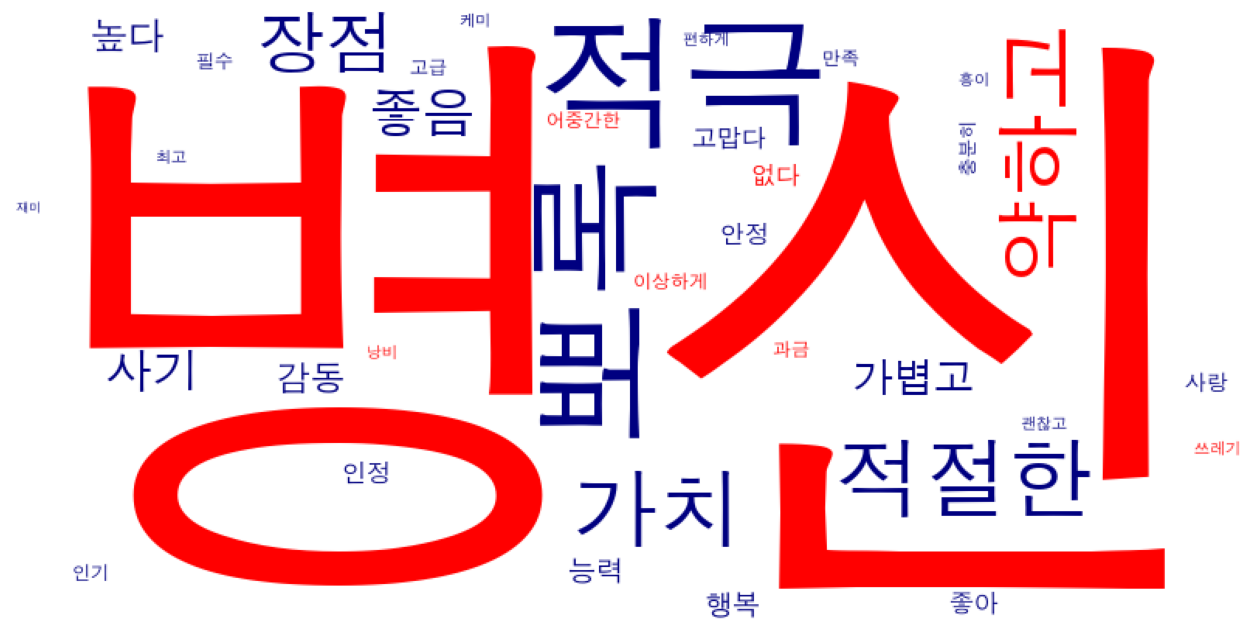

In [90]:
simple_color_func = SimpleGroupedColorFunc(color_to_words, default_color)
wc_frequencies = dict(zip(result_df['word'],result_df['count']))


wc = WordCloud(font_path='AppleGothic', scale=2.0, max_font_size=250, color_func = simple_color_func,
               background_color="white").generate_from_frequencies(wc_frequencies)
plt.figure(figsize = (16,  16))
plt.imshow(wc)
plt.axis("off")

### 3) 추천 정도 제안

# 백업

In [ ]:
# 단어와 polarity를 묶어서 딕셔너리로 저장
word_dic = dict(zip(word_df['word'], word_df['polarity']))

In [ ]:
# 클렌징된 토큰과 비교하여 점수 산출하기 - 테스트
word_dic.get(cleaned_token1[0],0)

0

In [ ]:
# 토큰별 점수 산출하여 새로운 데이터 프레임으로 저장
sentiment_df = pd.DataFrame(columns=('comment','sentiment'))

for idx, token in enumerate(cleaned_token1): 
    sentiment = int(word_dic.get(token,0))
    sentiment_df.loc[idx] = [token, sentiment]

KeyboardInterrupt: 

In [ ]:
sentiment_df

### 토큰화된 코멘트들과 감성어 사전 비교

In [68]:
# comment_point_df = pd.DataFrame(columns=['comment', 'point'])
# idx=0

# for token in cleaned_token1:
#     point = 0
#     for i in range(len(word_dic)):
#         if word_dic['word'][i] in token:
#             point += int(word_dic['polarity'][i])
#     comment_point_df.loc[idx] = [token,point]
#     idx += 1

KeyboardInterrupt: 

In [18]:
comment_point_df.head(3)

,comment,point
0,금 카 아직 현역 이 다 7 조대 가성 비 금흥 민 감차 치 달 퍼터 중거리 미쳤 ...,0
1,금 카 사용 중 CAP 보다 는 확실히 우위 의 22 시즌 나머지 120 오버 롤 ...,-3
2,24 토티 + 5 쓰 다가 급여 때문 에 이거 금 카로 넘어왔 는데 솔직히 블라인드...,0


In [20]:
# 재토큰화
re_token = [mecab.morphs(token) for token in tokens]
total_tokens = [token for word in re_token for token in word if len(token) > 1 ] # 글자수 2개 이상만 추출

In [22]:
# 토큰화된 형태소의 빈도수 계산
token_counter = Counter(total_tokens)

# 단어와 빈도수를 딕셔너리 자료료 바꾸서 key(단어)과 values(빈도수)를 데이터프레임으로 저장
count_tokens = pd.DataFrame(dict(token_counter).items(),columns=['word','count']) 
count_tokens

,word,count
0,아직,1
1,현역,2
2,조대,1
3,가성,6
4,금흥,1
...,...,...
892,대기,11
893,!!,11
894,혹시나,11
895,올라도,11


### 긍정 부정 라벨링

In [32]:
match_df = pd.merge(word_dic, count_tokens, how='inner', on='word')
match_df['polarity'] = match_df['polarity'].astype(int)
match_df['senti_cat'] = list(map(lambda x:'긍정' if  x> 0 else '부정' if x < 0 else '중립', match_df.polarity))

In [33]:
match_df

,word,word_root,polarity,count,senti_cat
0,^^,^^,1,12,긍정
1,가치,가치,1,33,긍정
2,감기,감기,-1,1,부정
3,감동,감동,2,11,긍정
4,감사,감사,2,12,긍정
5,고급,고급,2,1,긍정
6,과금,과,-1,1,부정
7,기대,기대,1,11,긍정
8,낭비,낭비,-1,1,부정
9,능력,능력,1,22,긍정


### 워드 클라우드 생성을 위한 설정

In [34]:
# 감성 단어군에 따라 색깔 지정
color_to_words = {
    'orange' : list(match_df.loc[match_df.senti_cat == '부정', 'word']),
    'navy': list(match_df.loc[match_df.senti_cat == '긍정', 'word'])}

default_color = 'grey'

# 각각의 단어에 색깔 지정
class SimpleGroupedColorFunc(object):
    def __init__(self, color_to_words, default_color):
        self.word_to_color = {word: color
                              for (color, words) in color_to_words.items()
                              for word in words}

        self.default_color = default_color

    def __call__(self, word, **kwargs):
        return self.word_to_color.get(word, self.default_color)

### 워드 클라우드 시각화

(np.float64(-0.5), np.float64(799.5), np.float64(399.5), np.float64(-0.5))

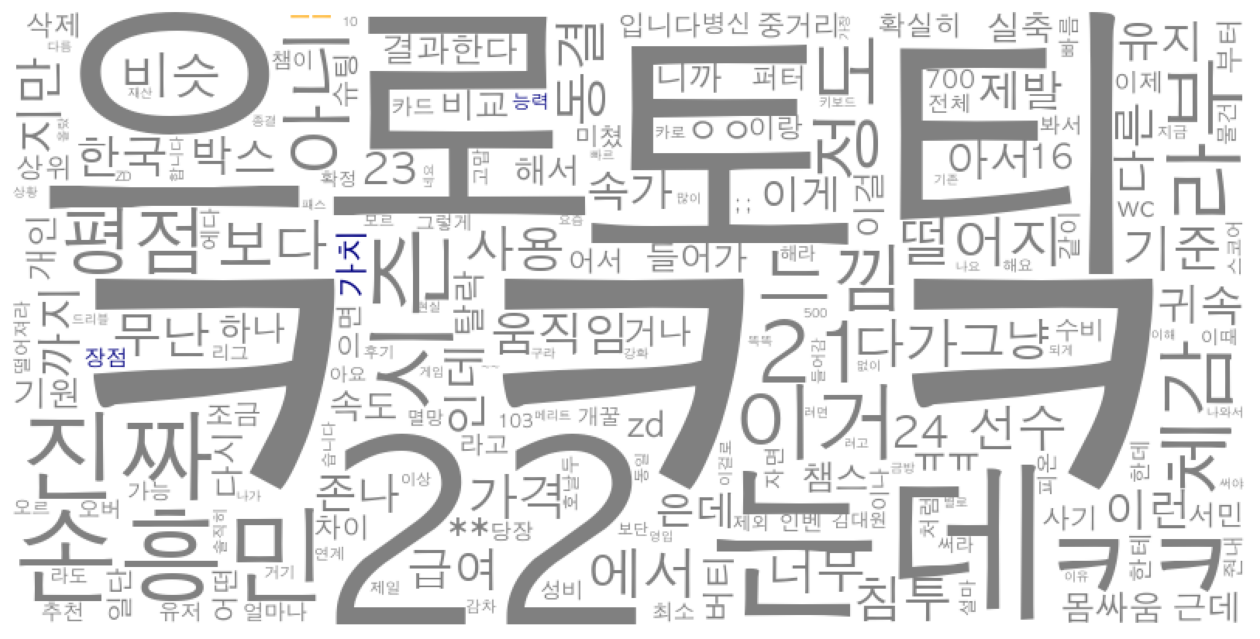

In [39]:
simple_color_func = SimpleGroupedColorFunc(color_to_words, default_color)

wc = WordCloud(font_path='AppleGothic', scale=2.0, max_font_size=250, color_func = simple_color_func,
               background_color="white").generate_from_frequencies(token_counter)
plt.figure(figsize = (16,  16))
plt.imshow(wc)
plt.axis("off")